In [5]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 763.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 94.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import random

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [7]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

print("Data ready. Shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data ready. Shape: (60000, 28, 28, 1)


In [8]:
def build_cnn(padding='valid', strides=(1,1), kernel_size=3):

    model = keras.Sequential([
        layers.Input(shape=(28,28,1)),

        layers.Conv2D(32, kernel_size,
                      padding=padding,
                      strides=strides,
                      activation='relu',
                      name="conv1"),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size,
                      padding=padding,
                      strides=strides,
                      activation='relu',
                      name="conv2"),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [9]:
experiments = [
    {"name": "Baseline (same padding, stride 1)", "padding": "same",  "strides": (1,1)},
    {"name": "No padding (valid), stride 1",      "padding": "valid", "strides": (1,1)},
    {"name": "Same padding, stride 2",            "padding": "same",  "strides": (2,2)},
    {"name": "Valid padding, stride 2",           "padding": "valid", "strides": (2,2)},
    {"name": "Same padding, stride 3",            "padding": "same",  "strides": (3,3)},
]

results = []
histories = {}

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"Running experiment: {exp['name']}")

    model = build_cnn(padding=exp["padding"], strides=exp["strides"])
    model.summary()

    start_time = time.time()

    history = model.fit(x_train, y_train,
                        batch_size=128,
                        epochs=8,
                        validation_split=0.1,
                        verbose=1)

    train_time = time.time() - start_time

    # inference timing
    start_inf = time.time()
    model.predict(x_test[:1000], verbose=0)
    inf_time = time.time() - start_inf

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "name": exp["name"],
        "padding": exp["padding"],
        "strides": exp["strides"],
        "train_time_sec": round(train_time, 2),
        "inference_time_sec": round(inf_time, 4),
        "test_accuracy": round(test_acc, 4),
        "final_val_acc": round(history.history['val_accuracy'][-1], 4),
        "num_params": model.count_params()
    })

    histories[exp["name"]] = history


Running experiment: Baseline (same padding, stride 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 10, 10, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7639 - loss: 0.7434 - val_accuracy: 0.9240 - val_loss: 0.2488
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9142 - loss: 0.2769 - val_accuracy: 0.9490 - val_loss: 0.1710
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9345 - loss: 0.2107 - val_accuracy: 0.9565 - val_loss: 0.1417
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9464 - loss: 0.1721 - val_accuracy: 0.9613 - val_loss: 0.1209
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9518 - loss: 0.1526 - val_accuracy: 0.9648 - val_loss: 0.1110
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9578 - loss: 0.1358 - val_accuracy: 0.9693 - val_loss: 0.0983
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9603 - loss: 0.1240 - val_accuracy: 0.9698 - val_loss: 0.0924
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9642 - loss: 0.1127 - val_accuracy: 0.9715 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


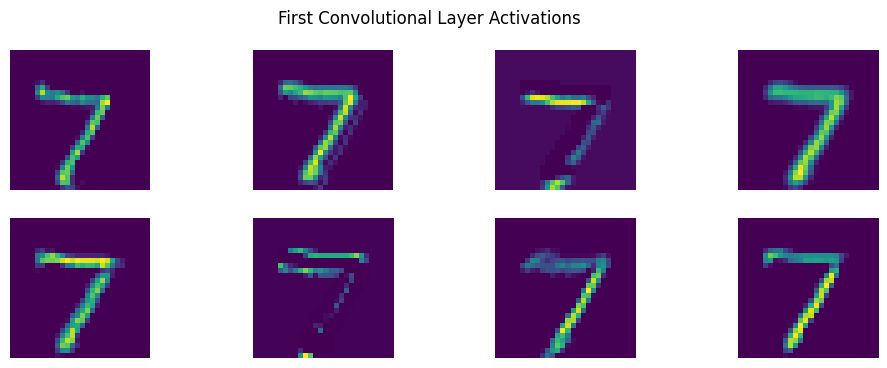

In [10]:
# Build baseline model
baseline_model = build_cnn("same", (1,1))

# IMPORTANT: build model graph explicitly
baseline_model.build(input_shape=(None, 28, 28, 1))

# (optional quick training to get meaningful filters)
baseline_model.fit(x_train, y_train, epochs=1, batch_size=128, verbose=0)

# Create intermediate model safely
intermediate_model = keras.Model(
    inputs=baseline_model.inputs,   # use .inputs instead of .input
    outputs=baseline_model.get_layer("conv1").output
)

# Get activations
act = intermediate_model.predict(x_test[:1])

plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(act[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First Convolutional Layer Activations")
plt.show()
